## Set up the notebook

In [2]:
"""
Load the content of this file in the jupyter notebook
using following commands:

import os
import jupconfig
%load {os.path.dirname(jupconfig.__file__)}/jupyter.py
"""

# Set aliases of frequently used jupyter magic commands
%alias_magic mi matplotlib -p inline
%alias_magic mn matplotlib -p notebook

# Set matplotlib backend (comment one or the other):
# - non-interactive plots displayed in a notebook cell
%matplotlib inline
# - interactive plots displayed in a notebook cell
# %matplotlib notebook (interactive version)

# Set matplotlib style
import matplotlib.pyplot as plt
plt.style.reload_library()
# print(plt.style.available) 
# combine styles (right overwrites left wherever they overlap):
plt.style.use(['default', 'plotea']) # this requires putting plotea/plotea.mplstyle
# in the right directory of your matplotlib installation
# plt.style.use(['default'])

# Configure logging -------------------------------------------

# 1. Set up loggers, handlers and load the log_lvl function
from jupconfig.loggers import *

# 2. Set level of log-messages
log_lvl(ERROR) # you can also use lll() alias
# Other options in order of increasing importance and 
# decreasing verbosity:
# TRACE, DEBUG, INFO, WARNING, ERROR, CRITICAL
# or using integers: 0, 10, 20, 30, 40, 50, respectively

# Autocompleting ----------------------------------------------
# (not sure if that works)
#%config IPCompleter.greedy=True 

# Automatically reload modules before execution
%load_ext autoreload
%autoreload 2

Created `%mi` as an alias for `%matplotlib inline`.
Created `%mn` as an alias for `%matplotlib notebook`.


## Import all the modules

In [4]:
from riverpy import *

## Read in the input data

In [5]:
log_lvl(20) # change verbosity of the logs (diagnostic messages), the higher the number, the less verbose
domain, topo, drain, dobs, dobs_unc, clusters, acq = InputPrep.run(dataset='ICL', river='wandle', 
                                                                   max_dist=100)
dataset = clusters.data_samples.dataset
catch = Catchment(dobs.graph.graph, drain.extent)

INFO:riverpy.input.Topography.extract: Extracting from ../../data/LIDAR_Composite_10m_DTM_2022.tif
INFO:riverpy.input.Drainage.extract: Extracting from ../../alex/thames-sewage/input_dir/thames_d8.nc
INFO:riverpy.input.DatasetICL.clean: Removing trailing spaces from columns names...
INFO:riverpy.input.DatasetICL.clean: Renaming some columns...
INFO:riverpy.input.DatasetICL.clean: Adding BNG coordinates as x,y columns...
INFO:riverpy.input.DatasetICL.clean: Adding 'campaign' column...
INFO:riverpy.input.DatasetICL.get_list_of_CECs: Added Tramadol & Carbamazepine which are not CECs but still worth looking.
INFO:riverpy.input.DatasetICL.get_list_of_CECs: Excluding Lincomycin - no data.
INFO:riverpy.input.DatasetICL.__init__: Min. measured concentration in the dataset: 3.47 ng/l


INFO:riverpy.input.DataSamples._cluster_dbscan: Output: {0: ['W21#1', 'W21#2', 'W21#3', 'W21#14', 'W21#4', 'W20#4', 'W20#1', 'W20#13'], 1: ['W21#13', 'W21#12', 'W21#18', 'W21#19', 'W21#20', 'W21#7', 'W20#9'], 2: ['W21#15', 'W20#2'], 3: ['W21#16', 'W20#5'], 4: ['W21#17', 'W21#10', 'W21#11', 'W20#8', 'W20#7'], 5: ['W21#21', 'W21#22', 'W21#23', 'W20#10'], 6: ['W21#24', 'W21#9', 'W20#12'], 7: ['W21#5', 'W20#3'], 8: ['W21#6', 'W20#6'], 9: ['W21#8', 'W20#11']}


## Pick the optimal regularisation

Pick the optimal $\lambda$ (regularisation strength) defined by the elbow (point of the maximum curvature) of the L-curve (plot of the data misfit vs. model roughness). Here we pick it by visual inspection of previously plotted L-curves. The implemented algorithm of automated search for the elbow point will be added soon.

In [15]:
lambda_dict = {k: 1.7 for k in dataset.cecs}
for k in ['Benzoylecgonine', 'Cocaine', 'Salicylic acid']:
    lambda_dict[k] = 2.2
lambda_dict

{'Acetamiprid': 1.7,
 'Azithromycin': 1.7,
 'Benzoylecgonine': 2.2,
 'Carbamazepine': 1.7,
 'Clarithromycin': 1.7,
 'Cocaine': 2.2,
 'Diclofenac': 1.7,
 'Imidacloprid': 1.7,
 'Salicylic acid': 2.2,
 'Sulfamethoxazole': 1.7,
 'Tramadol': 1.7,
 'Trimethoprim': 1.7,
 'Venlafaxine': 1.7}

## Apportion the sources

We will first initialise the framework that takes care of a multi-chemical source apportionment.

In [ ]:
wf = MultichemInversion('multichem01', 
                        InversionMC, # type of inversion (InversionMC - Monte Carlo inversion)
                        acq, # acquisition geometry object
                        detection_threshold=3, # ng/l
                        data=dobs, data_uncertainty=dobs_unc, 
                        extent=drain.extent, # spatial extent of apportionment
                        cp_norm=2, # p in the L^p, i.e. the vector norm used in the objective funciton
)

And then run the inversion...

In [28]:
%%time 
log_lvl(30)
wf.run(chems=dataset.cecs, # select contaminants of emerging concern analysed in the paper
       regularisation=lambda_dict, 
       n=1e2, # number of Monte Carlo runs
       std_is_relative=False, # define whether the input data_uncertainty is relative or absolute
       save=False, # save results as json files?
)

CPU times: user 6.2 s, sys: 24.4 ms, total: 6.22 s
Wall time: 6.25 s


{'Acetamiprid': <riverpy.frame.InversionMC at 0x2874c1150>,
 'Azithromycin': <riverpy.frame.InversionMC at 0x2874c1540>,
 'Benzoylecgonine': <riverpy.frame.InversionMC at 0x287a36620>,
 'Carbamazepine': <riverpy.frame.InversionMC at 0x287c2a530>,
 'Clarithromycin': <riverpy.frame.InversionMC at 0x287f2dc30>,
 'Cocaine': <riverpy.frame.InversionMC at 0x28822e4a0>,
 'Diclofenac': <riverpy.frame.InversionMC at 0x28843b580>,
 'Imidacloprid': <riverpy.frame.InversionMC at 0x2886329b0>,
 'Salicylic acid': <riverpy.frame.InversionMC at 0x288813d00>,
 'Sulfamethoxazole': <riverpy.frame.InversionMC at 0x288b35150>,
 'Tramadol': <riverpy.frame.InversionMC at 0x288d15c30>,
 'Trimethoprim': <riverpy.frame.InversionMC at 0x288f12530>,
 'Venlafaxine': <riverpy.frame.InversionMC at 0x289213520>}

# Plot results for a selected chemical

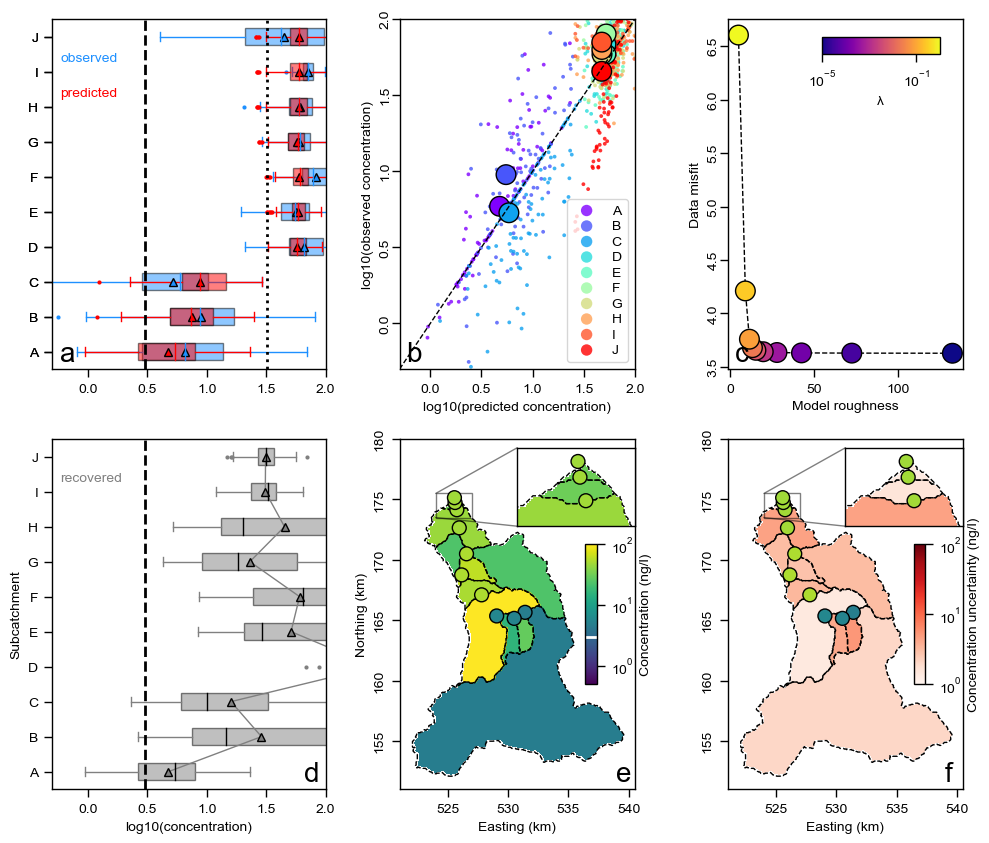

In [36]:
wf.inv['Imidacloprid'].plot_all(vmin=.5, vmax=1e2, vmin_std=1, vmax_std=100)

# Plot results for all chemicals

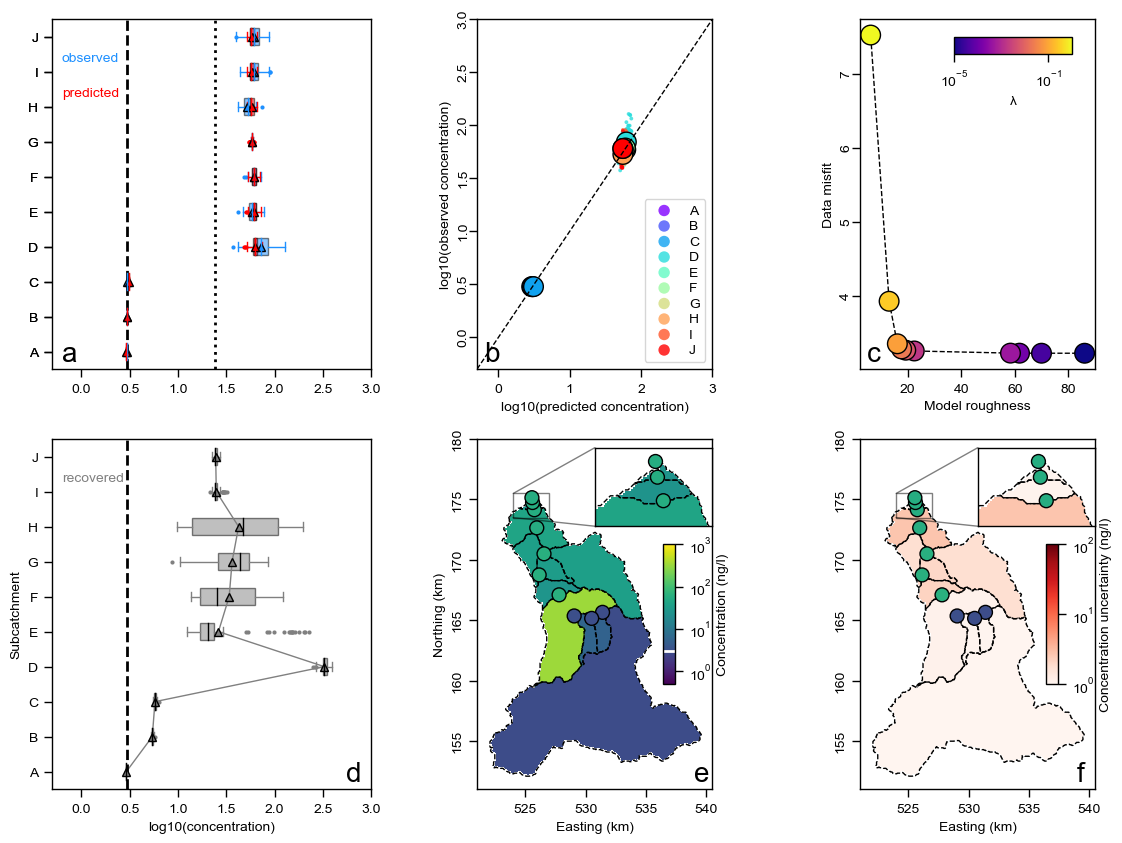

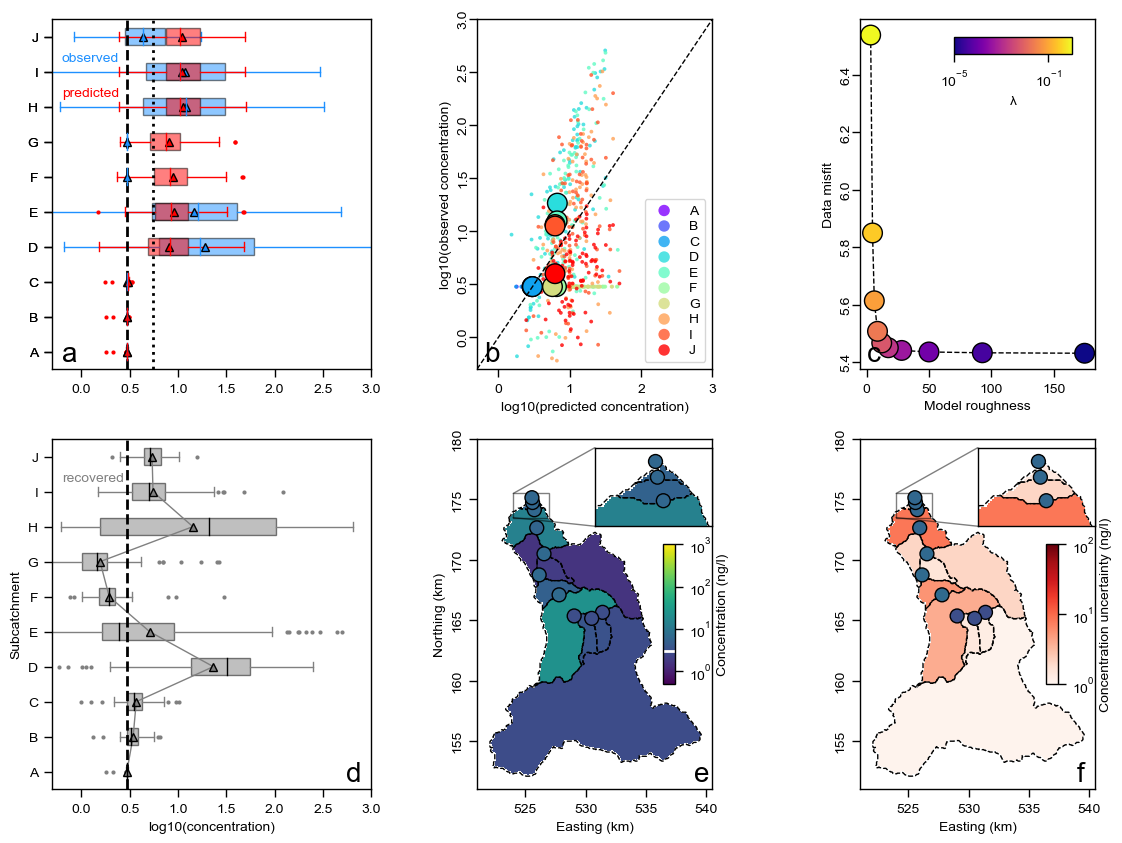

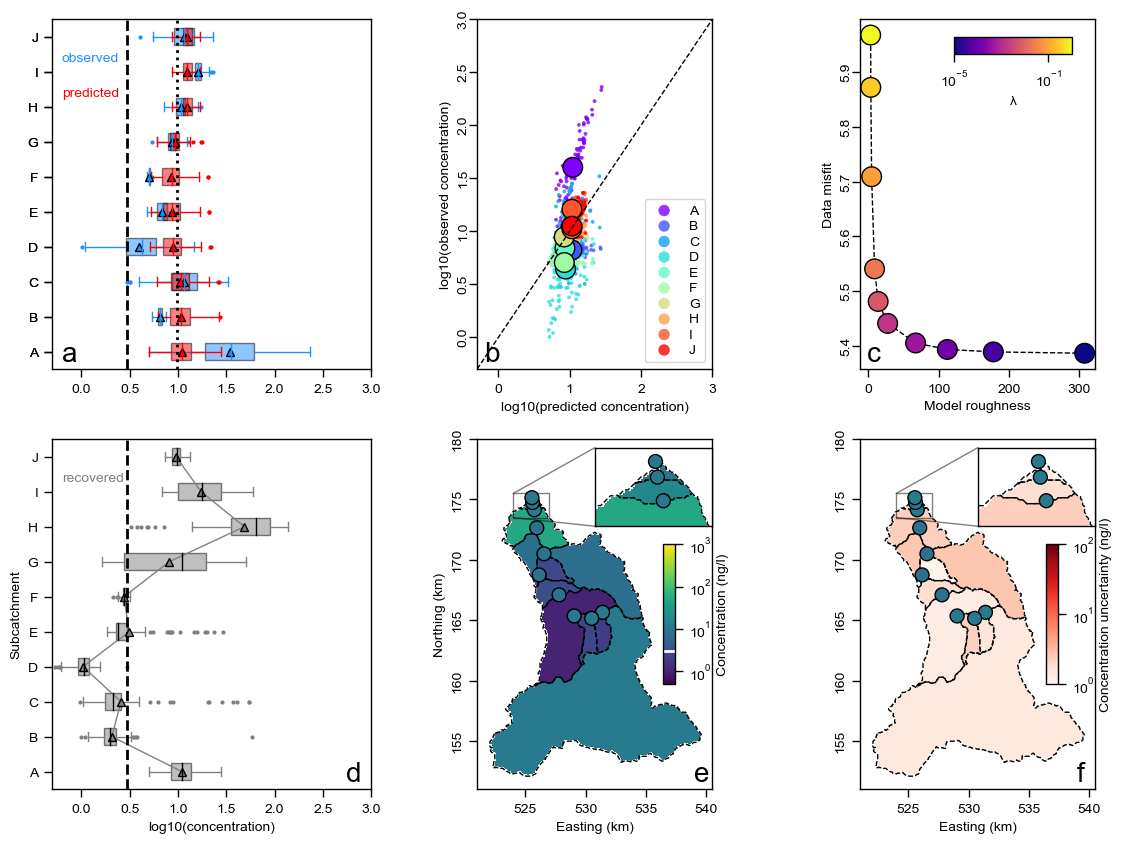

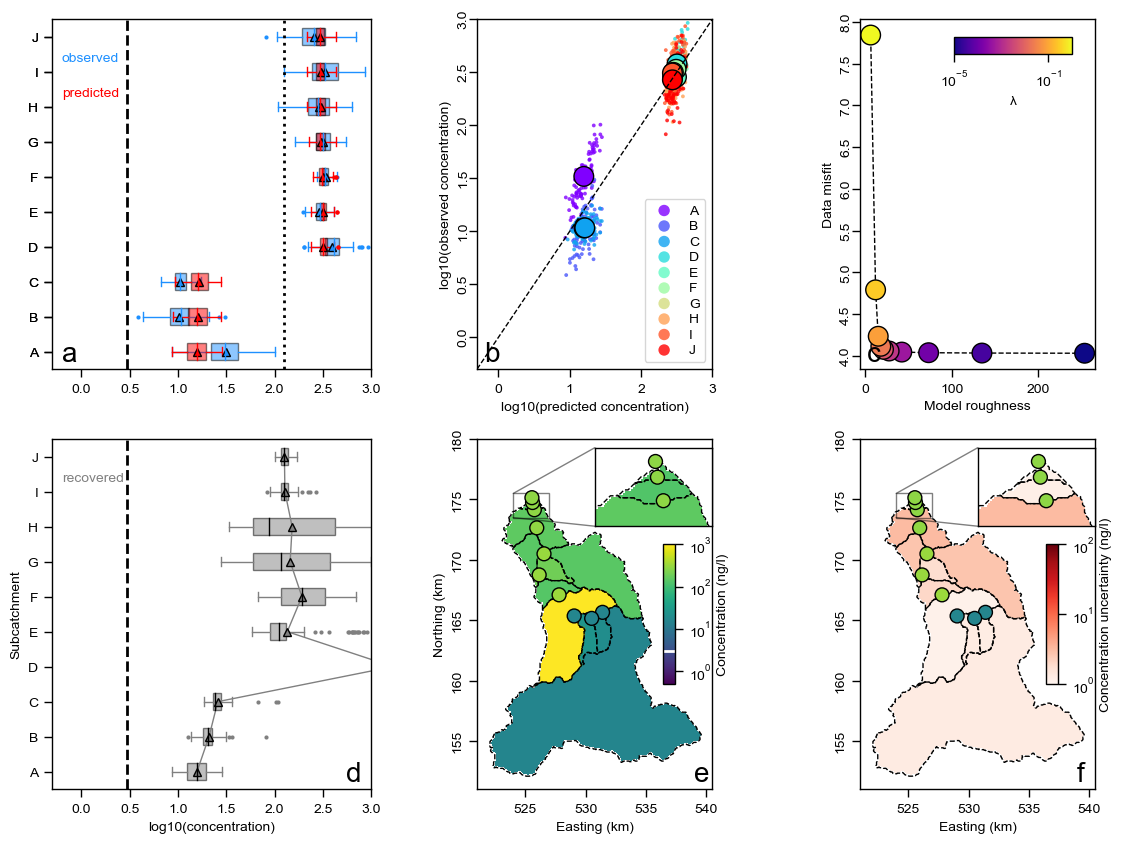

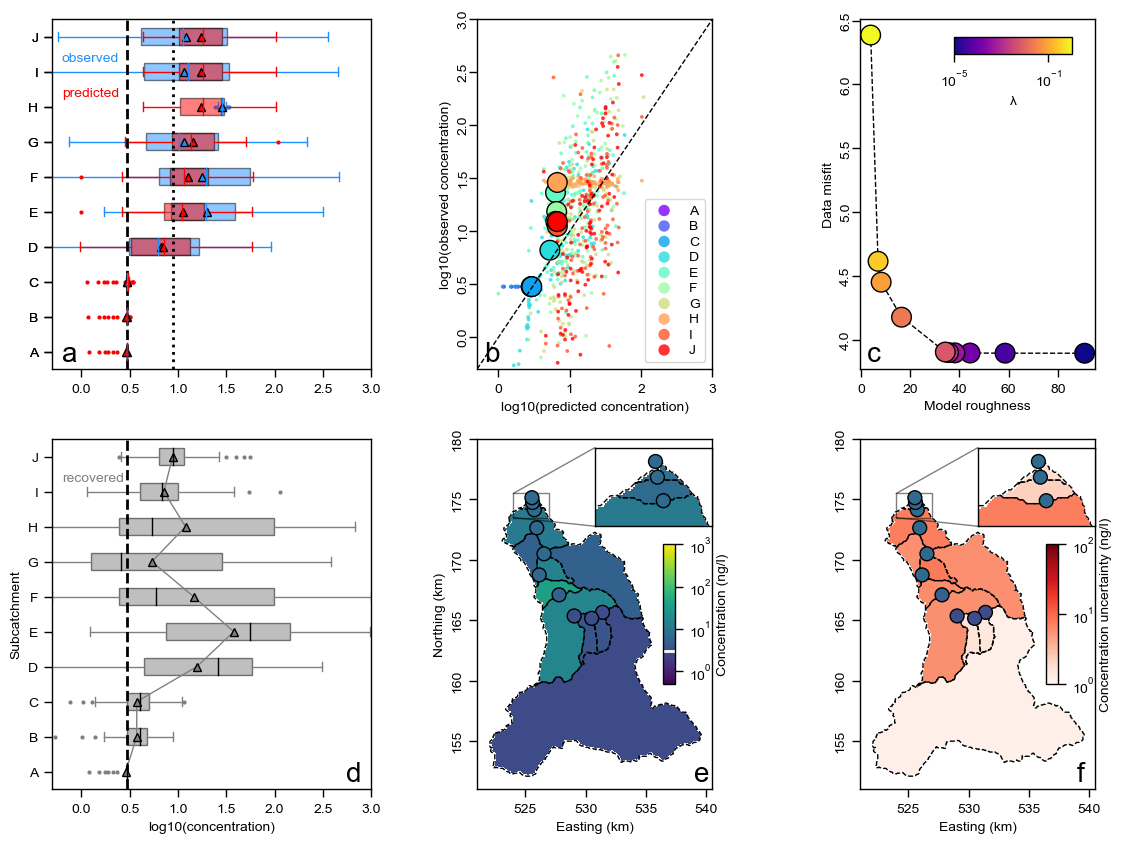

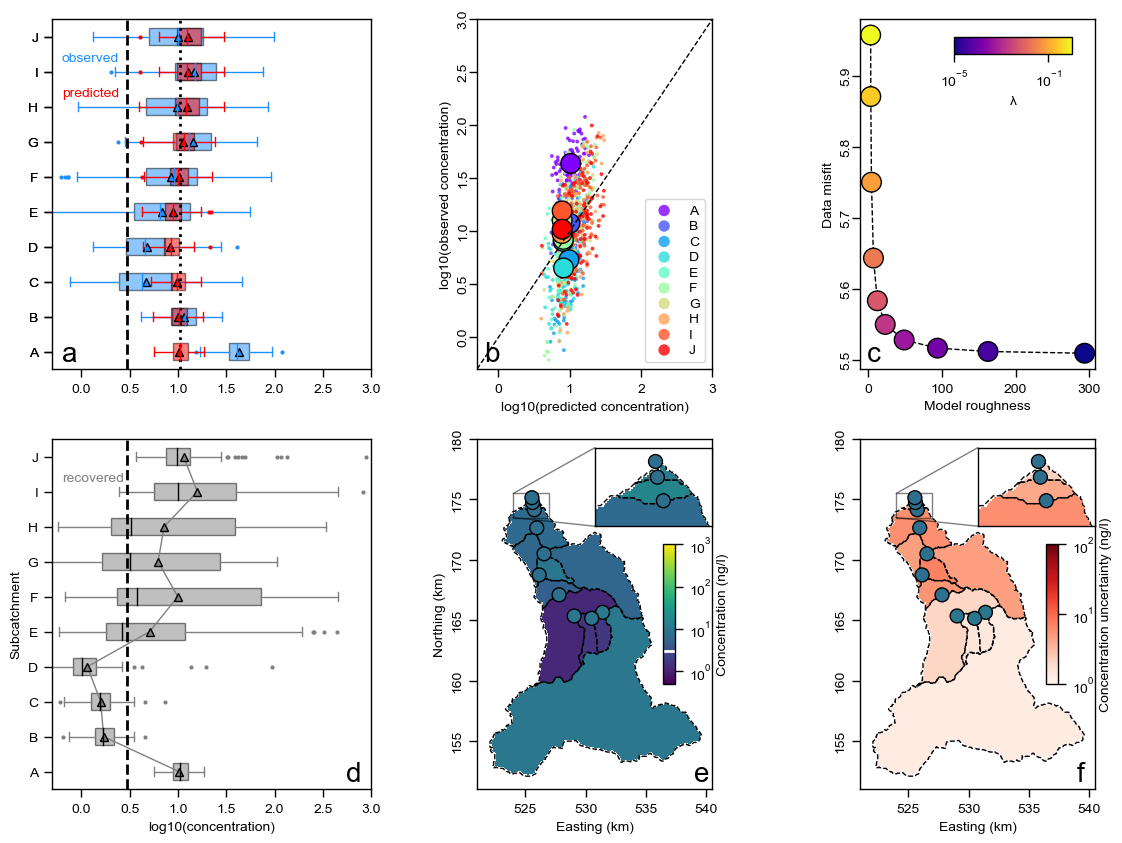

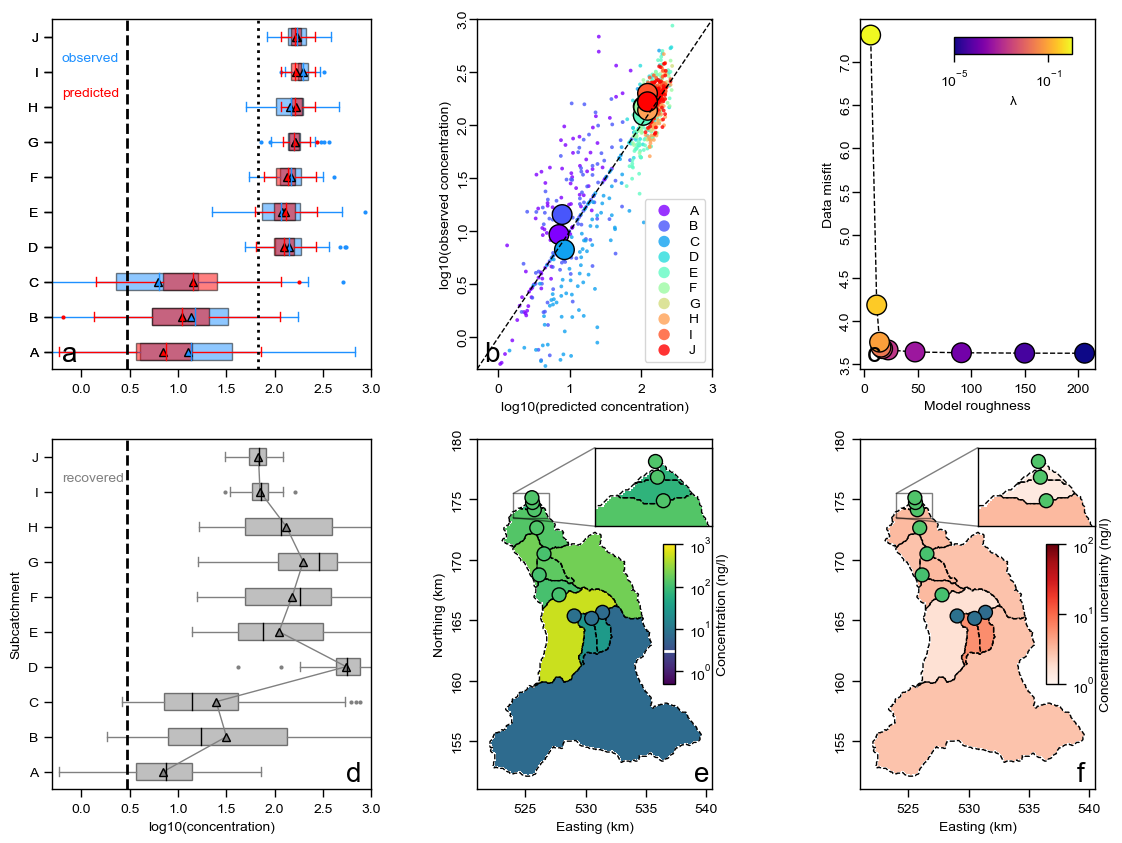

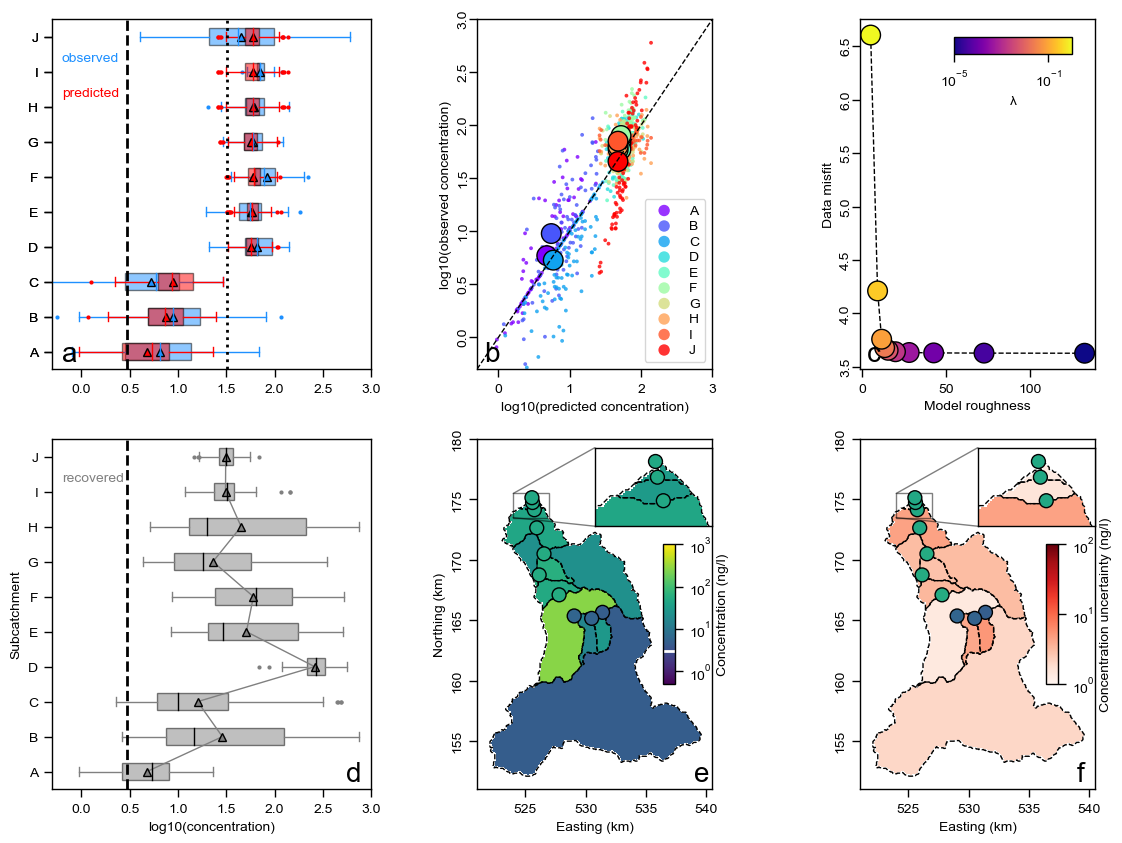

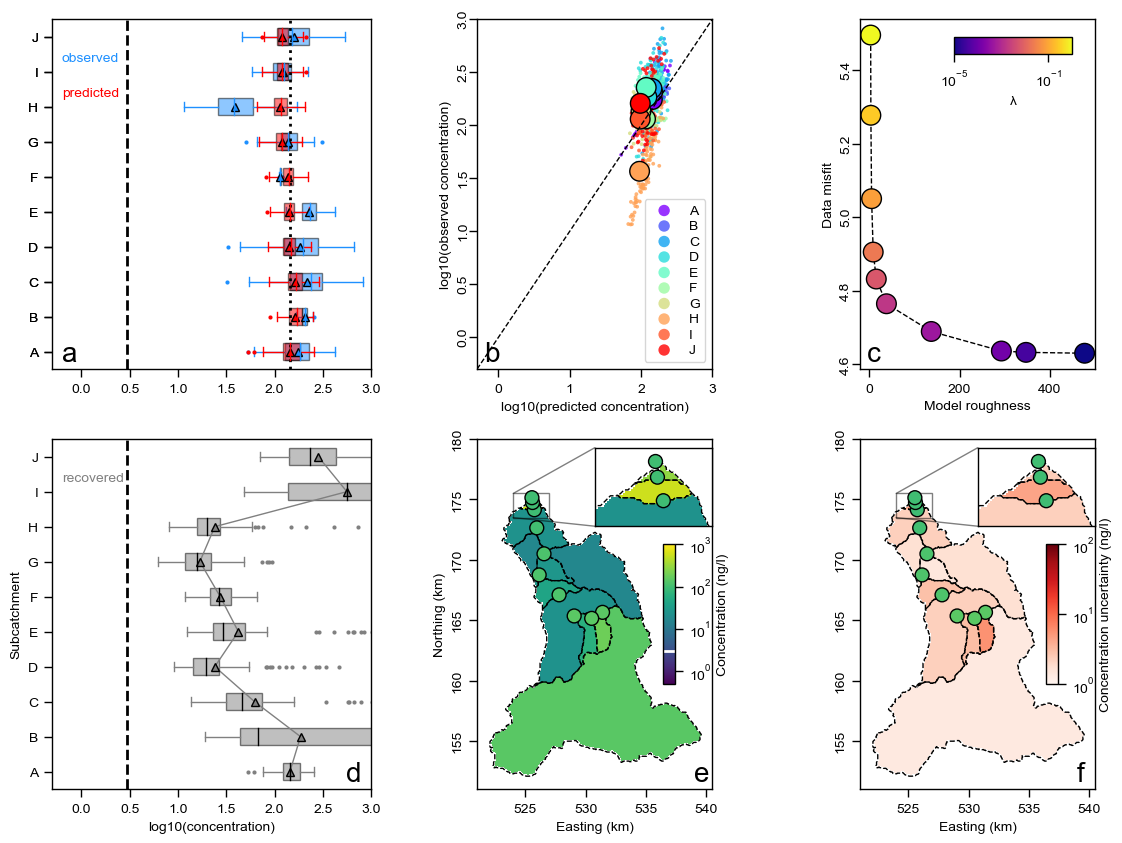

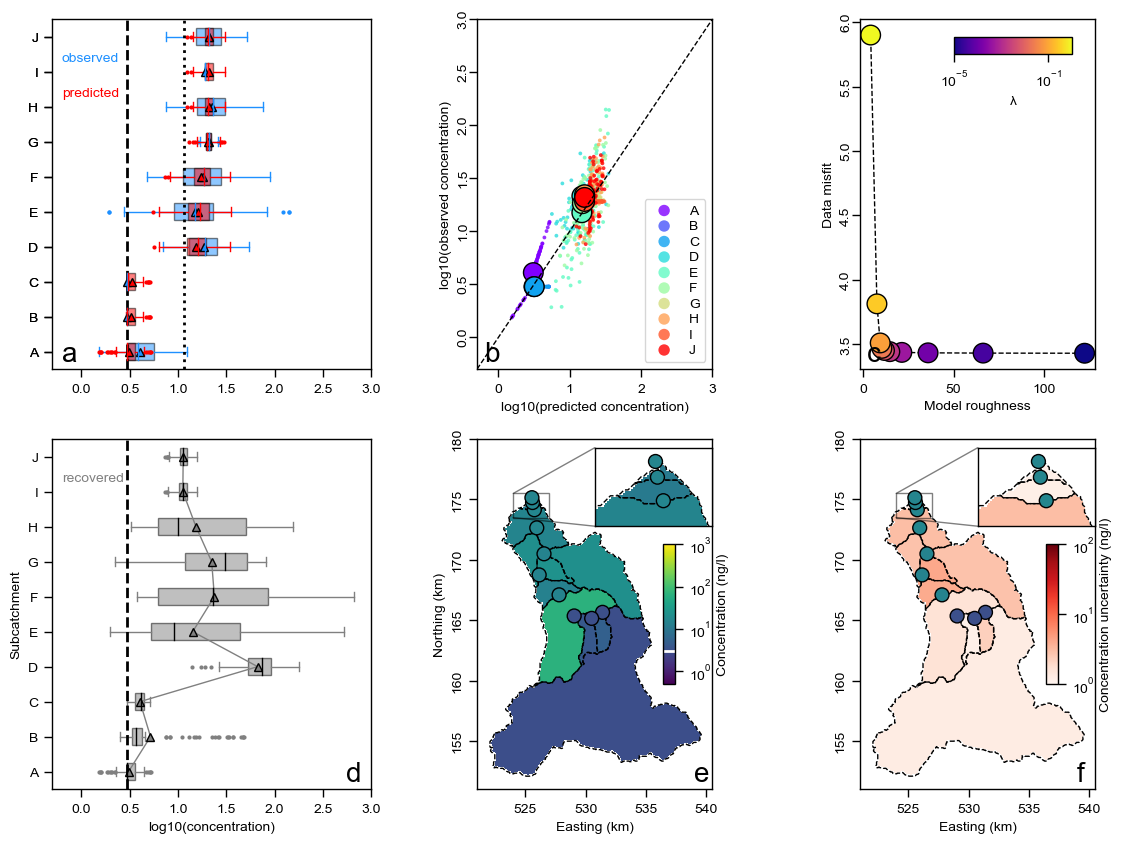

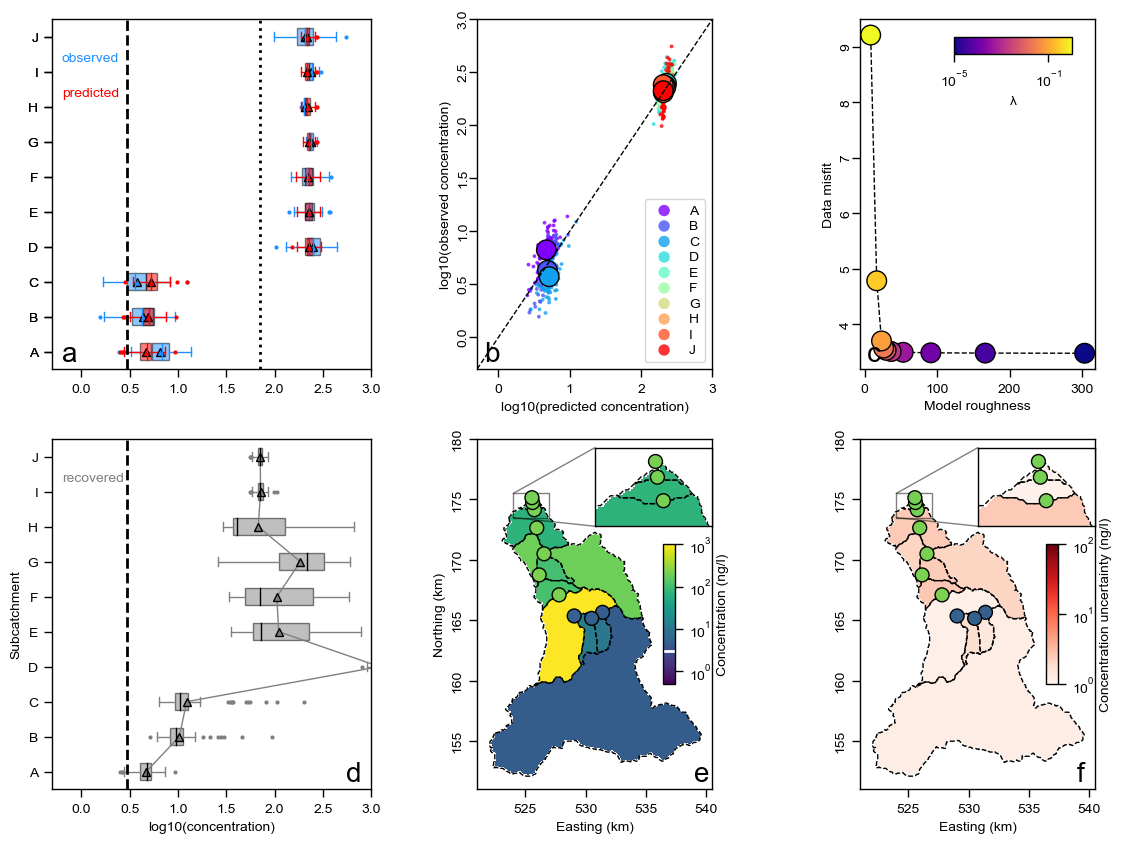

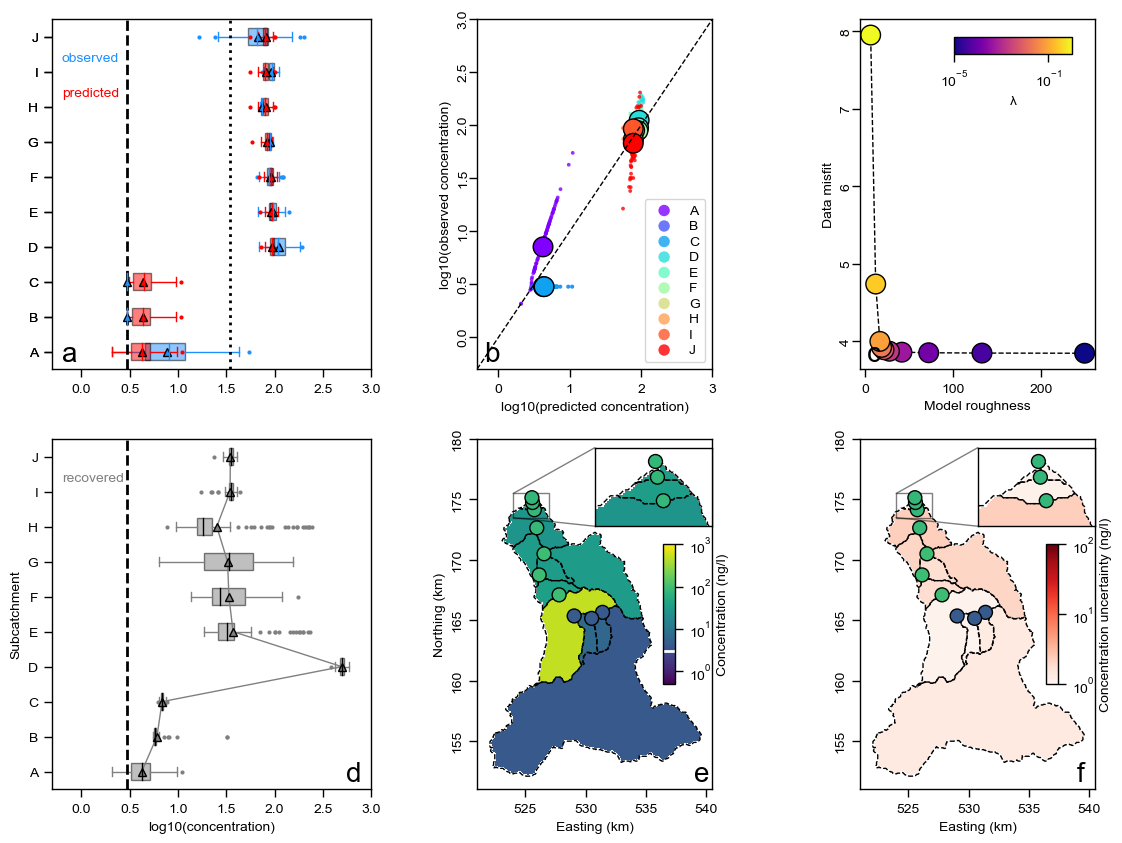

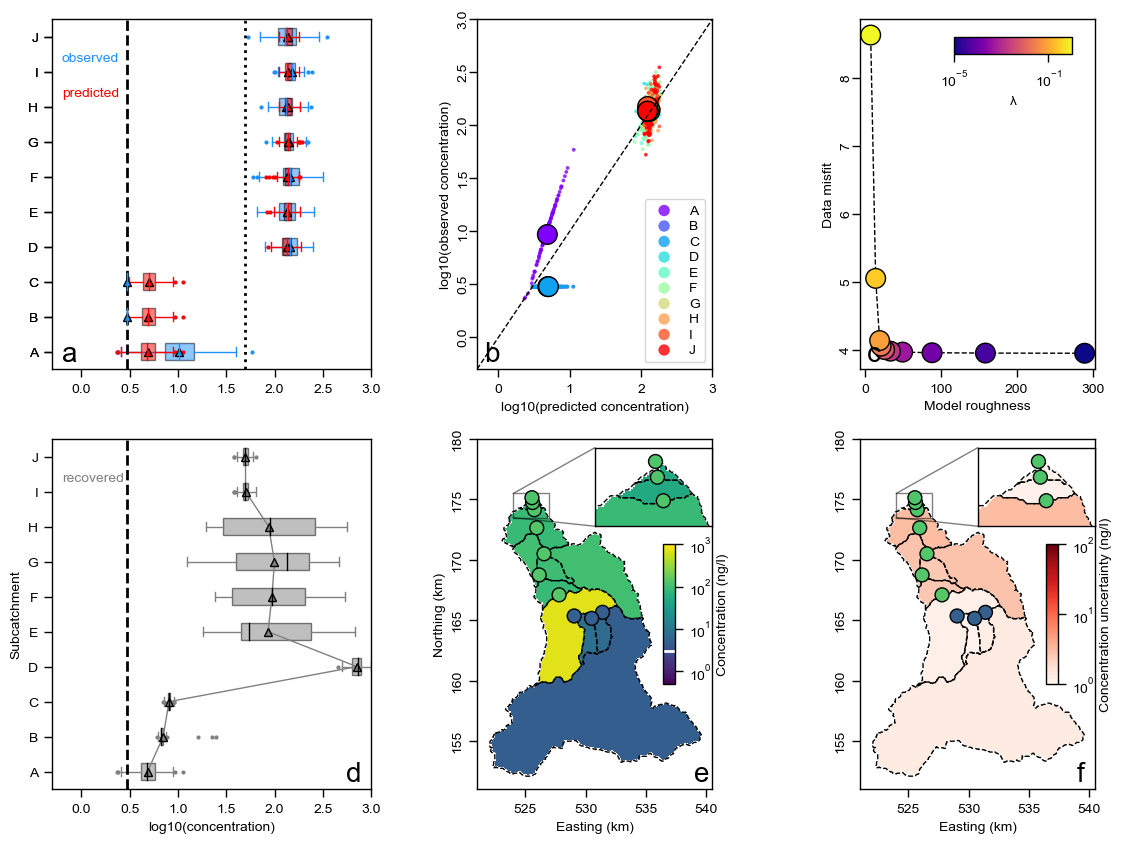

In [31]:
wf.plot()

In [39]:
%%time 
path = '../figures/apportionment/'
!mkdir {path}
wf.save(path, plots=True, results=False, extn='png')

mkdir: ../figures/apportionment/: File exists
CPU times: user 13.1 s, sys: 288 ms, total: 13.4 s
Wall time: 13.6 s


In [40]:
!ls {path}

Acetamiprid.png      Cocaine.png          Tramadol.png
Azithromycin.png     Diclofenac.png       Trimethoprim.png
Benzoylecgonine.png  Imidacloprid.png     Venlafaxine.png
Carbamazepine.png    Salicylic acid.png
Clarithromycin.png   Sulfamethoxazole.png


## ...